In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Pharma_Industry.csv')
display(df.head())

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

# ==========================================
# 1. DATA LOADING AND EXPLORATION
# ==========================================
print("="*60)
print("TASK 1: DATA EXPLORATION AND MISSING VALUES IMPUTATION")
print("="*60)

# Load dataset
df = pd.read_csv('/content/Pharma_Industry.csv') # Corrected filename

# Clean white spaces from string column fields
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Numerical Feature Distributions Summary ---")
print(df.describe().T)

# Identify census data missing values flagged as '?'
print("\n--- Identifying Hidden Missing Values ('?') ---")
missing_counts = {}
for col in df.columns:
    if df[col].dtype == 'object':
        # This part of the code assumes '?' as a missing value indicator, common in adult census data.
        # This might not be applicable to 'Pharma_Industry.csv' without modifications.
        zeros_q = (df[col] == '?').sum()
        if zeros_q > 0:
            missing_counts[col] = zeros_q
            print(f"Feature '{col}': found {zeros_q} entries containing '?'")

# Best Practice Imputation: Replacing '?' with the mode (most frequent value) of each column
df_clean = df.copy()
for col in missing_counts.keys():
    mode_value = df_clean[df_clean[col] != '?'][col].mode()[0]
    df_clean[col] = df_clean[col].replace('?', mode_value)

if missing_counts:
    print("\nMissing values imputed using mode replacement.")
else:
    print("\nNo '?' hidden missing values found or imputed.")

# ==========================================
# 2. NUMERICAL FEATURE SCALING
# ==========================================
print("\n" + "="*60)
print("TASK 2: NUMERICAL SCALING (STANDARD VS MIN-MAX)")
print("="*60)

numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical variables identified for scaling: {list(numerical_cols)}")

# Standard Scaling (Z-score)
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df_clean[numerical_cols]), columns=numerical_cols)

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df_clean[numerical_cols]), columns=numerical_cols)

print("\nSample Standard Scaled Outputs (First 2 rows):")
print(df_standard.head(2))
print("\nSample Min-Max Scaled Outputs (First 2 rows):")
print(df_minmax.head(2))

# ==========================================
# 3. CATEGORICAL VARIABLE ENCODING
# ==========================================
print("\n" + "="*60)
print("TASK 3: CATEGORICAL VARIABLE ENCODING")
print("="*60)

# The .drop('income') assumes an 'income' column, which may not exist in Pharma_Industry.csv.
# This line will need adjustment if 'income' is not present.
if 'income' in df_clean.columns:
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.drop('income')
else:
    categorical_cols = df_clean.select_dtypes(include=['object']).columns

print("Categorical Feature Profile:")
for col in categorical_cols:
    print(f"  - {col}: {df_clean[col].nunique()} categories")

# Rules applied according to criteria:
# One-Hot Encoding if categories < 5 (e.g., sex, race)
# Label Encoding if categories >= 5 (e.g., workclass, education, occupation, marital_status, relationship, native_country)

df_encoded = df_clean.copy()
one_hot_targets = []
label_encode_targets = []

for col in categorical_cols:
    if df_clean[col].nunique() < 5:
        one_hot_targets.append(col)
    else:
        label_encode_targets.append(col)

print(f"\nTargeting for One-Hot Encoding (<5 categories): {one_hot_targets}")
print(f"Targeting for Label Encoding (>=5 categories): {label_encode_targets}")

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_targets, drop_first=True)

# Perform Label Encoding
label_encoders = {}
for col in label_encode_targets:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

print(f"\nFinal Preprocessed Data Shape (post-encoding): {df_encoded.shape}")

# ==========================================
# 4. FEATURE ENGINEERING & SKEWNESS TRANSFORMATION
# ==========================================
print("\n" + "="*60)
print("TASK 4: FEATURE ENGINEERING AND TRANSFORMATIONS")
print("="*60)

# Check Skewness of numerical features
print("Feature Skewness Metrics:")
print(df_clean[numerical_cols].skew())

# Metric Transformation: Log Transformation on heavily skewed 'capital_gain'
# log1p is used to handle 0 values safely: log(x + 1)
# These columns might not exist in 'Pharma_Industry.csv'
if 'capital_gain' in df_encoded.columns:
    df_encoded['capital_gain_log'] = np.log1p(df_encoded['capital_gain'])
    print("\n--- Justification for Log Transformation ---")
    print(f"Original 'capital_gain' skewness: {df_clean['capital_gain'].skew():.4f}")
    print(f"Log Transformed 'capital_gain_log' skewness: {df_encoded['capital_gain_log'].skew():.4f}")
else:
    print("\n'capital_gain' column not found for log transformation.")

# Engineering Feature 1: Hours per year (hours_per_week * 52)
if 'hours_per_week' in df_encoded.columns:
    df_encoded['hours_per_year'] = df_encoded['hours_per_week'] * 52
else:
    print("\n'hours_per_week' column not found for feature engineering.")

# Engineering Feature 2: Capital Balance Net Flow (capital_gain - capital_loss)
if 'capital_gain' in df_encoded.columns and 'capital_loss' in df_encoded.columns:
    df_encoded['net_capital_flow'] = df_encoded['capital_gain'] - df_encoded['capital_loss']
else:
    print("\n'capital_gain' or 'capital_loss' columns not found for feature engineering.")

print("\nSuccessfully engineered new structural features:")
print("1. 'hours_per_year' (Total annual committed work hours) - if columns existed")
print("2. 'net_capital_flow' (Net continuous investment balance return) - if columns existed")

# ==========================================
# 5. ADVANCED DETECTION: ISOLATION FOREST OUTLIERS
# ==========================================
print("\n" + "="*60)
print("TASK 5: ADVANCED OUTLIER DETECTION VIA ISOLATION FOREST")
print("="*60)

# Isolate features matrix for anomaly detection (ignoring target string feature 'income')
# This assumes an 'income' column exists and is the target.
if 'income' in df_encoded.columns:
    X_iso = df_encoded.drop(columns=['income'])
else:
    # If 'income' doesn't exist, we'll try to drop 'Drug Response' as a potential target
    if 'Drug Response' in df_encoded.columns:
        X_iso = df_encoded.drop(columns=['Drug Response'])
        print("Using 'Drug Response' as target for outlier detection (if applicable).")
    else:
        X_iso = df_encoded.copy()
        print("No specific target column found; using all features for outlier detection.")

iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
outlier_preds = iso_forest.fit_predict(X_iso)

# -1 represents an outlier, 1 represents normal data
df_encoded['is_outlier'] = outlier_preds
outliers_count = (df_encoded['is_outlier'] == -1).sum()

print(f"Total rows flagged as multivariate outliers (at 2% contamination threshold): {outliers_count}")
print(f"Clean rows kept for training matrix structures: {(df_encoded['is_outlier'] == 1).sum()}")
print("="*60)

TASK 1: DATA EXPLORATION AND MISSING VALUES IMPUTATION
Dataset Shape: 500 rows, 6 columns

--- Numerical Feature Distributions Summary ---
                                count      mean       std       min       25%  \
Drug Dosage (mg)                500.0 -0.037761  0.979891 -3.019512 -0.642003   
Systolic Blood Pressure (mmHg)  500.0  0.214957  1.247567 -3.773897 -0.565168   
Heart Rate (BPM)                500.0  0.062871  0.971978 -2.940389 -0.648157   
Liver Toxicity Index (U/L)      500.0  0.054398  0.986001 -3.401277 -0.586085   
Blood Glucose Level (mg/dL)     500.0 -0.171863  0.983765 -3.110431 -0.797715   
Drug Response                   500.0  0.520000  0.500100  0.000000  0.000000   

                                     50%       75%       max  
Drug Dosage (mg)               -0.019340  0.641151  2.949094  
Systolic Blood Pressure (mmHg)  0.201532  0.951375  4.111751  
Heart Rate (BPM)                0.027732  0.710774  3.193108  
Liver Toxicity Index (U/L)     -0.065661 

### Correlation Analysis of Numerical Features

Let's analyze the correlation between the numerical features in the `df_clean` DataFrame. A correlation matrix and heatmap will help us identify relationships between different variables.

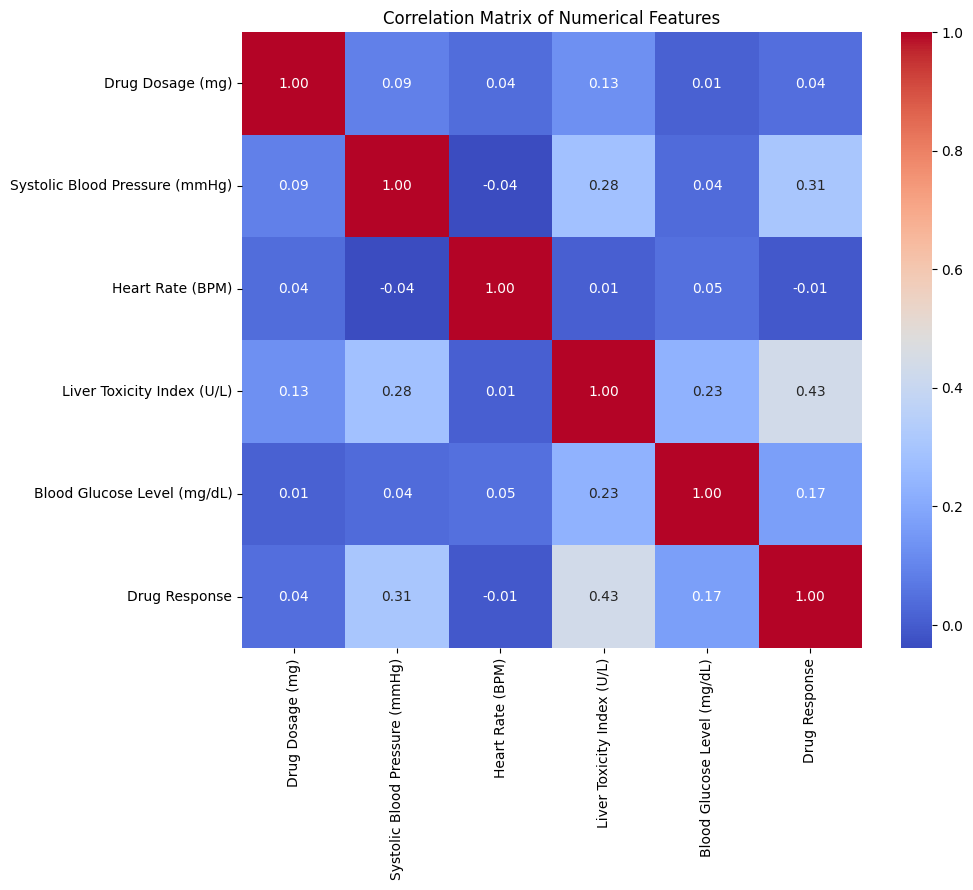

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_clean[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Filtering Outliers for Training

Now, let's filter out the rows that were flagged as outliers by the Isolation Forest. This will create a clean dataset `df_cleaned_for_training` that can be used for model training.

In [7]:
# Filter out the outliers (where is_outlier == -1)
df_cleaned_for_training = df_encoded[df_encoded['is_outlier'] != -1].copy()

print(f"Original DataFrame shape: {df_encoded.shape}")
print(f"DataFrame shape after removing outliers: {df_cleaned_for_training.shape}")

display(df_cleaned_for_training.head())

Original DataFrame shape: (500, 7)
DataFrame shape after removing outliers: (490, 7)


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response,is_outlier
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0,1
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1,1
5,-0.535963,0.070851,0.808058,0.330542,-0.065926,0,1


### Classification Model Performance Evaluation

Now that we have a cleaned dataset, let's prepare it for classification, train a model, and evaluate its performance using a confusion matrix.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define features (X) and target (y)
# We'll drop 'is_outlier' and 'Drug Response' from features as 'Drug Response' is our target
X = df_cleaned_for_training.drop(columns=['Drug Response', 'is_outlier'])
y = df_cleaned_for_training['Drug Response']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (343, 5)
X_test shape: (147, 5)
y_train shape: (343,)
y_test shape: (147,)


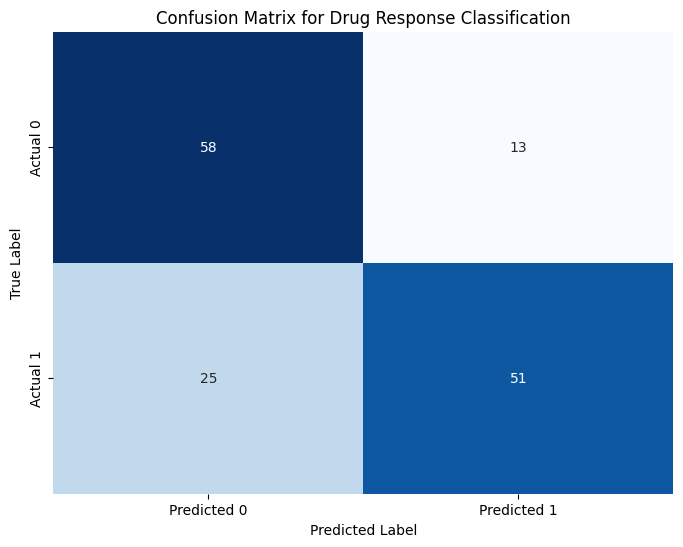

In [9]:
# Initialize and train a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Drug Response Classification')
plt.show()